In [1]:
import sys
sys.path.append('..')
import nimo
import yaml
import shutil

In [2]:
# Parameters cell for papermill
config_file = "nts_settings.tmpl.yaml"  # This will be overwritten by papermill

In [3]:
# Parameters
config_file = "./configs/nts_conservative_batch24_trial1.yaml"


In [4]:
# Load configuration from YAML file
with open(config_file, "r") as f:
    config = yaml.safe_load(f)

### AIとロボットのサイクルの回数を設定

In [5]:
# CyclesNum will be calculated from total_eval / batch_size

### 目的関数の次元を設定

In [6]:
ObjectivesNum = config["objectives_num"]

In [7]:
from descriptor import Desctiptor
des = Desctiptor()

### 実験条件候補データファイル名および提案条件のファイル名を設定

In [8]:
from pathlib import Path

TRIAL = config["trial"]
BATCH_SIZE = int(config["batch_size"])
TOTAL_EVAL = int(config["total_eval"])
INITIAL_BATCH_SIZE = int(config["initial_batch_size"])
CyclesNum = int((TOTAL_EVAL - INITIAL_BATCH_SIZE) / BATCH_SIZE)
print(f"CyclesNum: {CyclesNum}")
NTS_MODE = config["nts_mode"]
RE_SEED = config["re_seed"]
USE_DPP = config["use_dpp"]

if NTS_MODE == "conservative":
    MODE = nimo.Mode.conservative
elif NTS_MODE == "moderate":
    MODE = nimo.Mode.moderate
elif NTS_MODE == "aggressive":
    MODE = nimo.Mode.aggressive
print(MODE)

# Create output directory with batch size in name
out_dir = Path(f"./data_{NTS_MODE}_batch{BATCH_SIZE}_trial{TRIAL}")
out_dir.mkdir(exist_ok=True, parents=True)
(out_dir / "fig").mkdir(exist_ok=True, parents=True)

# Copy setting yaml file to output directory
shutil.copy(config_file, out_dir / Path(config_file).name)

CyclesNum: 28
Mode.conservative


PosixPath('data_conservative_batch24_trial1/nts_conservative_batch24_trial1.yaml')

In [9]:
candidates_file = out_dir / f"descriptor_search_space_{NTS_MODE}_batch{BATCH_SIZE}_trial{TRIAL}.csv"
proposals_file = out_dir / f"descriptor_proposals_{NTS_MODE}_batch{BATCH_SIZE}_trial{TRIAL}.csv"

# Copy initial search space to output directory if not exists
import os
initial_search_space = f"./descriptor_search_space_{NTS_MODE}_batch{BATCH_SIZE}_trial{TRIAL}.csv"
if os.path.exists(initial_search_space) and not os.path.exists(candidates_file):
    shutil.copy(initial_search_space, candidates_file)

### 結果を格納する場所を作成

In [10]:
res_history = nimo.history(input_file = str(candidates_file),
                             num_objectives = ObjectivesNum)

### 最適化計算

In [11]:
import time
start = time.time()
for K in range(CyclesNum+1):

    #最初のサイクルではランダムに実験条件を提案させる
    if K == 0:
        nimo.selection(method = "RE",
                       input_file = str(candidates_file),
                       output_file = str(proposals_file),
                       num_objectives = ObjectivesNum,
                       num_proposals = INITIAL_BATCH_SIZE,
                       re_seed = RE_SEED)

    #2回目以降のサイクルではAIを使用して実験条件を提案
    else:
        nimo.selection(method = "NTS",
                       input_file = str(candidates_file),
                       output_file = str(proposals_file),
                       num_objectives = ObjectivesNum,
                       num_proposals = BATCH_SIZE,
                       sample_mode=MODE,
                       use_dpp=USE_DPP,
                       output_res=True)

    #実験条件に従い，ロボット実験のインプットファイルを作成する
    import preparation_input_functions
    preparation_input_functions.ORIGINAL(input_file = str(proposals_file),
                                         input_folder = str(out_dir)).perform()

    #実験終了後，測定データを解析し，目的関数をアップデートする
    import analysis_output_functions_SO_descriptor
    analysis_output_functions_SO_descriptor.ORIGINAL(input_file = str(proposals_file),
                                       output_file = str(candidates_file),
                                       num_objectives = ObjectivesNum,
                                       output_folder = str(out_dir)).perform()

    #結果をプロットするためのhistoryを格納する
    res_history = nimo.history(input_file = str(candidates_file),
                               num_objectives = ObjectivesNum,
                               itt = K,
                               history_file = res_history)

    #結果のヒストグラムを作成するモジュールを読み出す
    if K % 5 == 0:
        import time
        time.sleep(1)
        nimo.visualization.plot_distribution.plot(input_file = str(candidates_file),
                                                  num_objectives = ObjectivesNum,
                                                  fig_folder = str(out_dir / "fig"))

end = time.time()
print(f"Elapsed time: {end - start} [s]")

Start selection of proposals by RE!


Proposals
###
number = 1
actions =  6971
proposal =  [2.6 1.2 1.5]
###
###
number = 2
actions =  10353
proposal =  [3.6 1.3 3. ]
###
###
number = 3
actions =  16184
proposal =  [3.2 1.5 1.5]
###
###
number = 4
actions =  6363
proposal =  [0.9 1.2 3.6]
###
###
number = 5
actions =  13028
proposal =  [2.8 1.4 0.4]
###
###
number = 6
actions =  13663
proposal =  [4.5 1.4 1. ]
###
###
number = 7
actions =  5558
proposal =  [6.9 1.1 0.8]
###
###
number = 8
actions =  6344
proposal =  [0.9 1.2 1.7]
###
###
number = 9
actions =  13816
proposal =  [4.9 1.4 1.5]
###
###
number = 10
actions =  7526
proposal =  [4.1 1.2 1.5]
###
###
number = 11
actions =  6006
proposal =  [0.  1.2 1.2]
###
###
number = 12
actions =  15171
proposal =  [0.5 1.5 0.1]
###
###
number = 13
actions =  13639
proposal =  [4.4 1.4 2.3]
###
###
number = 14
actions =  12567
proposal =  [1.5 1.4 2.4]
###
###
number = 15
actions =  9101
proposal =  [0.2 1.3 3.6]
###
###
number = 16
actions =  12390
proposal =  [1.  1.4 3.2]
##

Start selection of proposals by NTS!
--------------------------------------------------------------------------------
         Use physbo.search.discrete.Policy instead.
--------------------------------------------------------------------------------


lstar: 1.1531379482000002


Selected actions: [np.int64(11820), np.int64(17522), np.int64(4515), np.int64(16694), np.int64(11965), np.int64(14925), np.int64(11786), np.int64(15773), np.int64(17176), np.int64(2374), np.int64(1796), np.int64(9803), np.int64(4109), np.int64(6596), np.int64(9259), np.int64(14231), np.int64(11774), np.int64(9850), np.int64(6330), np.int64(9226), np.int64(17035), np.int64(14708), np.int64(14678), np.int64(17078)]
Proposals
###
number = 1
actions =  11820
proposal =  [7.6 1.3 1.7]
###
###
number = 2
actions =  17522
proposal =  [6.8 1.5 2.1]
###
###
number = 3
actions =  4515
proposal =  [4.1 1.1 0.1]
###
###
number = 4
actions =  16694
proposal =  [4.6 1.5 0.7]
###
###
number = 5
actions =  11965
proposal =  [8.  1.3 1.4]
###
###
number = 6
actions =  14925
proposal =  [7.9 1.4 1.4]
###
###
number = 7
actions =  11786
proposal =  [7.5 1.3 2. ]
###
###
number = 8
actions =  15773
proposal =  [2.1 1.5 1.1]
###
###
number = 9
actions =  17176
proposal =  [5.9 1.5 0.8]
###
###
number = 10


...

Start selection of proposals by NTS!


lstar: 1.2118788328999999


Selected actions: [np.int64(3742), np.int64(1287), np.int64(951), np.int64(3040), np.int64(15269), np.int64(15181), np.int64(10981), np.int64(2002), np.int64(16010), np.int64(196), np.int64(15397), np.int64(12683), np.int64(14197), np.int64(2079), np.int64(907), np.int64(4656), np.int64(15007), np.int64(9052), np.int64(12572), np.int64(15020), np.int64(17198), np.int64(2003), np.int64(15355), np.int64(3063)]
Proposals
###
number = 1
actions =  3742
proposal =  [2.  1.1 0.5]
###
###
number = 2
actions =  1287
proposal =  [3.4 1.  2.9]
###
###
number = 3
actions =  951
proposal =  [2.5 1.  2.6]
###
###
number = 4
actions =  3040
proposal =  [0.1 1.1 0.6]
###
###
number = 5
actions =  15269
proposal =  [0.7 1.5 2.5]
###
###
number = 6
actions =  15181
proposal =  [0.5 1.5 1.1]
###
###
number = 7
actions =  10981
proposal =  [5.3 1.3 2.9]
###
###
number = 8
actions =  2002
proposal =  [5.4 1.  0.4]
###
###
number = 9
actions =  16010
proposal =  [2.7 1.5 2.6]
###
###
number = 10
actions = 

lstar: 1.2123979545


Selected actions: [np.int64(12004), np.int64(2748), np.int64(17081), np.int64(1222), np.int64(2467), np.int64(8154), np.int64(15085), np.int64(12984), np.int64(16883), np.int64(13788), np.int64(9054), np.int64(13772), np.int64(16287), np.int64(12050), np.int64(28), np.int64(13357), np.int64(17004), np.int64(9055), np.int64(5144), np.int64(16213), np.int64(15067), np.int64(3061), np.int64(6931), np.int64(15392)]
Proposals
###
number = 1
actions =  12004
proposal =  [0.  1.4 1.6]
###
###
number = 2
actions =  2748
proposal =  [7.4 1.  1. ]
###
###
number = 3
actions =  17081
proposal =  [5.6 1.5 2.4]
###
###
number = 4
actions =  1222
proposal =  [3.3 1.  0.1]
###
###
number = 5
actions =  2467
proposal =  [6.6 1.  2.5]
###
###
number = 6
actions =  8154
proposal =  [5.8 1.2 1.4]
###
###
number = 7
actions =  15085
proposal =  [0.2 1.5 2.6]
###
###
number = 8
actions =  12984
proposal =  [2.6 1.4 3.4]
###
###
number = 9
actions =  16883
proposal =  [5.1 1.5 1.1]
###
###
number = 10
actio

### 目的関数の推移を出力

In [12]:
nimo.visualization.plot_history.cycle(input_file = res_history,
                                      num_cycles = CyclesNum,
                                      fig_folder = str(out_dir / "fig"))

In [13]:
import numpy as np
tmp = []
X_tmp = []
for r in res_history:
    tmp.append(r[2][0])
    X_tmp.append(r[1])

tmp = np.array(tmp)
X_tmp = np.array(X_tmp)

In [14]:
from collections import defaultdict
sample_by_iter, objective_by_iter = defaultdict(list), defaultdict(list)
for r in res_history:
    objective_by_iter[r[0]].append(r[2][0])
    sample_by_iter[r[0]].append(r[1])

dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29])


Text(0, 0.5, 'Objective')

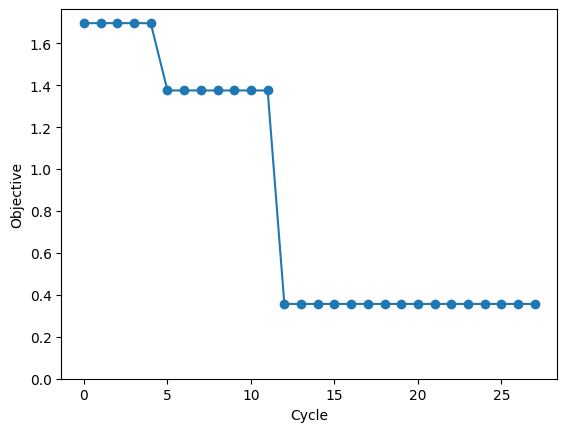

In [15]:
import matplotlib.pyplot as plt

print(objective_by_iter.keys())

fig, ax = plt.subplots()
tmp_history = [des.get_regret(max(objective_by_iter[1]))]
for i in range(1, CyclesNum):
    tmp_history.append(min(tmp_history[-1], des.get_regret(max(objective_by_iter[i]))))
ax.plot(range(CyclesNum), tmp_history, marker="o")
ax.set_xlabel("Cycle")
ax.set_ylim(0)
ax.set_ylabel("Objective")

In [16]:
# Save nested list object
import pickle
with open(out_dir / "objective_by_iter.pkl", "wb") as f:
    pickle.dump(objective_by_iter, f)
with open(out_dir / "sample_by_iter.pkl", "wb") as f:
    pickle.dump(sample_by_iter, f)